In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [82]:
#reads the dataset
data = pd.read_csv("spam.csv",encoding="latin-1")
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


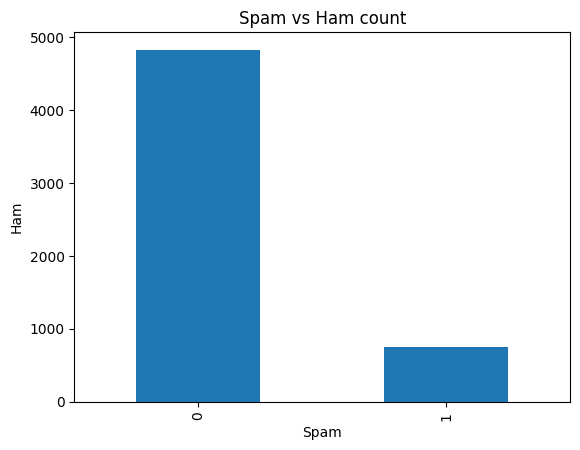

In [92]:
data['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham count")
plt.xlabel("Spam")
plt.ylabel("Ham")
plt.show()

In [84]:

data = data[['v1','v2']]
data.columns = ['label', 'message']
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [85]:
data['label']=data['label'].map({'ham':0,'spam':1})
data.head()

/tmp/ipython-input-3820436421.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['label']=data['label'].map({'ham':0,'spam':1})


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [86]:
x= data['message']
y= data['label']

In [87]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [88]:
# converts text to numbers
vector= TfidfVectorizer()
x_train_vec=vector.fit_transform(x_train)
x_test_vec=vector.transform(x_test)

In [89]:
model= MultinomialNB()
model.fit(x_train_vec,y_train)

MultinomialNB()

In [90]:
#accuracy check
y_pred = model.predict(x_test_vec)
accuracy= accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.9641255605381166


In [91]:
sample_sms=["Congrats! You Have Won a Prize"]
sample_vector=vector.transform(sample_sms)
prediction=model.predict(sample_vector)
if prediction[0]==1:
    print("spam")
else:
    print("ham")


spam
